In [2]:
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "../requirements.txt"])

0

In [3]:
import geopandas as gpd
import rasterio
import numpy as np
import matplotlib.pyplot as plt

print("All libraries loaded correctly!")

All libraries loaded correctly!


### 1.1 Load Burned Areas
We load the annual burned area shapefiles for each year (2021–2024). Each file contains 
the perimeters of areas affected by fire that year.

In [7]:
import geopandas as gpd

burned_2021 = gpd.read_file("../data/raw/Territórios_Ardidos/ardida_2021/ardida_2021.shp")
burned_2022 = gpd.read_file("../data/raw/Territórios_Ardidos/ardida_2022/ardida_2022.shp")
burned_2023 = gpd.read_file("../data/raw/Territórios_Ardidos/ardida_2023/ardida_2023.shp")
burned_2024 = gpd.read_file("../data/raw/Territórios_Ardidos/ardida_2024/ardida_2024.shp")

print("2021:", burned_2021.shape)
print("2022:", burned_2022.shape)
print("2023:", burned_2023.shape)
print("2024:", burned_2024.shape)

2021: (918, 23)
2022: (1786, 24)
2023: (1736, 24)
2024: (1558, 23)


### 1.2 Check Coordinate Reference Systems
Before merging the layers we verify that all datasets share the same coordinate 
reference system (CRS). Inconsistent CRS would cause spatial misalignment.

In [8]:
print("2021 CRS:", burned_2021.crs)
print("2022 CRS:", burned_2022.crs)
print("2023 CRS:", burned_2023.crs)
print("2024 CRS:", burned_2024.crs)

2021 CRS: EPSG:3763
2022 CRS: EPSG:3763
2023 CRS: EPSG:3763
2024 CRS: EPSG:3763


### 1.3 Merge Burned Areas into a Single Cumulative Layer
We combine the four annual layers into one dataset representing all areas 
burned at least once between 2021 and 2024. We add a year column first so 
we can still tell which fire belongs to which year after merging.

In [9]:
import pandas as pd

# Add a year column to each before merging
burned_2021["year"] = 2021
burned_2022["year"] = 2022
burned_2023["year"] = 2023
burned_2024["year"] = 2024

# Keep only the columns we need to avoid the column mismatch issue
cols = ["year", "geometry"]
burned_all = pd.concat([
    burned_2021[cols],
    burned_2022[cols],
    burned_2023[cols],
    burned_2024[cols]
])

# Reset index
burned_all = burned_all.reset_index(drop=True)

print("Total fire perimeters:", len(burned_all))
print(burned_all.head())

Total fire perimeters: 5998
   year                                           geometry
0  2021  POLYGON ((91853.576 232910.448, 91861.167 2329...
1  2021  POLYGON ((101406.3 168809.703, 101410.269 1688...
2  2021  POLYGON ((111535.884 170107.817, 111535.222 17...
3  2021  MULTIPOLYGON (((-55661.361 -253385.417, -55657...
4  2021  POLYGON ((-49809.417 -284169.64, -49765.761 -2...


### 1.4 Visualise Cumulative Burned Areas
A quick map to confirm the data loaded and merged correctly, with each 
year shown in a different colour.

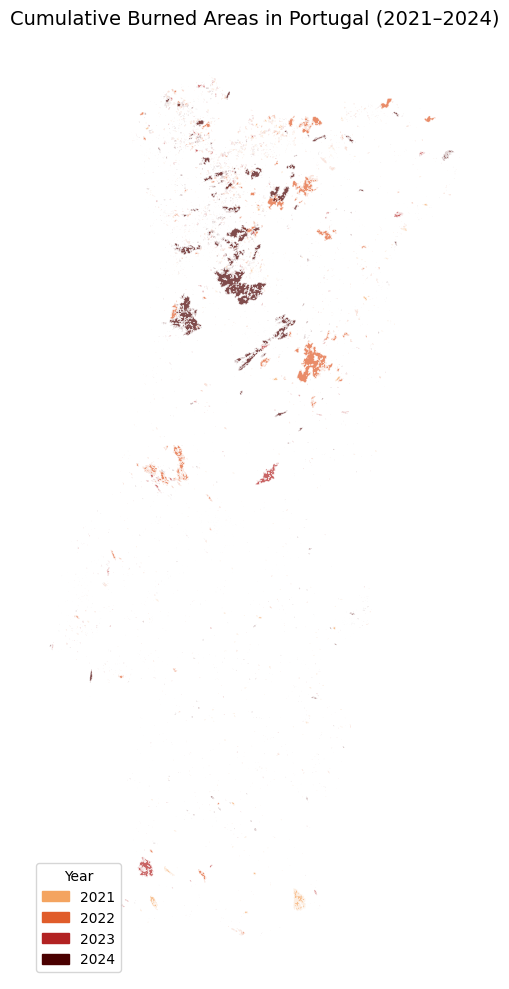

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(8, 10))

colors = {2021: "#f4a460", 2022: "#e05c2a", 2023: "#b22222", 2024: "#4a0000"}

for year, color in colors.items():
    burned_all[burned_all["year"] == year].plot(
        ax=ax, color=color, linewidth=0.3, edgecolor="white", alpha=0.7
    )

# Legend
patches = [mpatches.Patch(color=c, label=str(y)) for y, c in colors.items()]
ax.legend(handles=patches, title="Year", loc="lower left")

ax.set_title("Cumulative Burned Areas in Portugal (2021–2024)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/burned_areas_2021_2024.png", dpi=150)
plt.show()

### 1.5 Load Portugal Boundaries
We download Portugal's boundary directly from a public source to use as 
a background for our maps.

(1, 169)


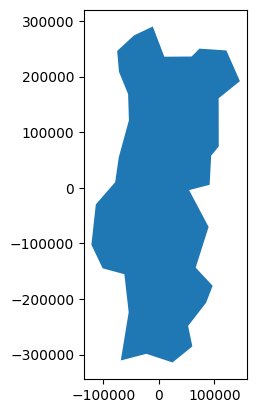

In [12]:
import geopandas as gpd

# Download world boundaries directly
world = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")
portugal = world[world["NAME"] == "Portugal"].to_crs("EPSG:3763")

print(portugal.shape)
portugal.plot()
plt.show()